# 10 — Dinâmica nacional: uma equação própria para a inadimplência

Esta etapa é uma extensão informada pelos resultados anteriores. Consulte `docs/segunda_etapa_protocolo.md`, registrado no GitHub antes dos testes. Precedência preditiva e associações condicionais não identificam causalidade estrutural.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT/'src'))
from segunda_etapa import *
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize':(12,5),'font.size':11})
pd.set_option('display.max_columns', 20)
def tabela(d):
    display(d.round(5))
def resumo(d):
    tabela(d.groupby(['Família','Período','Categoria resultado']).size().reset_index(name='Modelos'))


## 1. Retomada sem recalcular 05–09
A tabela anterior é lida e as hipóteses repetidas por AIC/BIC são contadas uma única vez. Os hashes das entradas são preservados. A taxa nacional é reconstruída pela razão das somas de carteiras.

In [2]:
tabela(previous())
s=historical_series()
tabela(s.describe().T)

,Métrica,Valor
0,Hipóteses distintas,235
1,Rejeições nominais,29
2,Rejeições BH,0
3,Nominais com autocorrelação sistema,18
4,Nominais com triagem favorável,4


,count,mean,std,min,25%,50%,75%,max
I,144.0,3.842491,0.457574,2.847982,3.595593,3.839813,4.13564,5.032363
Total nacional,144.0,280.131944,188.756447,48.0,157.5,235.0,357.25,1408.0
Grupo | Climatológico,144.0,135.541667,115.726944,12.0,50.5,105.5,179.25,603.0
Grupo | Hidrológico,144.0,107.006944,114.97099,1.0,33.5,69.5,141.0,802.0
Grupo | Meteorológico,144.0,25.805556,31.914282,1.0,7.75,15.5,30.25,283.0
Grupo | Outros,144.0,11.777778,11.542227,0.0,5.0,10.0,15.0,84.0
Tipologia | Alagamentos,144.0,10.444444,9.810639,0.0,3.75,8.0,15.0,60.0
Tipologia | Chuvas Intensas,144.0,56.138889,81.314516,0.0,8.75,26.0,63.0,467.0
Tipologia | Doenças infecciosas,144.0,1.6875,9.153293,0.0,0.0,0.0,1.0,78.0
Tipologia | Enxurradas,144.0,19.159722,20.558177,0.0,6.0,14.0,27.0,117.0


## 2. Por que ordens diferentes?
O VAR anterior obrigava o mesmo lag nas duas equações. Aqui ΔI tem lags próprios selecionados por BIC e um termo sazonal no lag12. A exposição possui de um a três lags; médias sazonais são controladas com 11 dummies. A amostra comum impede que um candidato pareça melhor apenas por usar outras datas. O ótimo incluindo q=0 é registrado. As ordens positivas selecionadas não tornam o teste confirmatório: a incerteza pós-seleção permanece.

In [3]:
r=read('nacional') if (OUT/'nacional_historico_bruto.csv').exists() else national()
resumo(r)
tabela(r[['Período','Exposição','Família','p próprio','q exposição','q0 preferido','n efetivo','p clássico','p','p BH','BG1 p','BG12 p','CUSUM p','Raiz própria','Diagnóstico favorável']])

,Família,Período,Categoria resultado,Modelos
0,DETERMINISTICAS,Total (2013–2024),Diagnósticos inadequados ou inconclusivos,21
1,NACIONAL,Pré-pandemia (até jan/2020),Diagnósticos inadequados ou inconclusivos,19
2,NACIONAL,Pré-pandemia (até jan/2020),Excluído / inviável,2
3,NACIONAL,Total (2013–2024),Diagnósticos inadequados ou inconclusivos,21


,Período,Exposição,Família,p próprio,q exposição,q0 preferido,n efetivo,p clássico,p,p BH,BG1 p,BG12 p,CUSUM p,Raiz própria,Diagnóstico favorável
0,Total (2013–2024),Total nacional,NACIONAL,1.0,1.0,True,131.0,0.39215,0.32059,0.85229,0.07015,0.68681,0.63950,0.86528,False
1,Total (2013–2024),Grupo | Climatológico,NACIONAL,1.0,1.0,True,131.0,0.70722,0.77458,1.00000,0.06339,0.69780,0.65545,0.85765,False
2,Total (2013–2024),Grupo | Hidrológico,NACIONAL,1.0,1.0,True,131.0,0.76878,0.66720,1.00000,0.06332,0.71378,0.66018,0.85848,False
3,Total (2013–2024),Grupo | Meteorológico,NACIONAL,1.0,1.0,True,131.0,0.84352,0.75882,1.00000,0.08211,0.69085,0.66107,0.85789,False
4,Total (2013–2024),Grupo | Outros,NACIONAL,1.0,1.0,True,131.0,0.32454,0.33664,0.85229,0.11486,0.54418,0.66538,0.86503,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,Total (2013–2024),Tipologia | Onda de Frio,DETERMINISTICAS,1.0,1.0,True,131.0,0.11616,0.00825,0.10318,0.02978,0.64530,0.61751,0.82890,False
59,Total (2013–2024),Tipologia | Outros,DETERMINISTICAS,1.0,1.0,True,131.0,0.84644,0.80681,1.00000,0.02748,0.55757,0.60812,0.83543,False
60,Total (2013–2024),Tipologia | Rompimento/Colapso de barragens,DETERMINISTICAS,1.0,1.0,True,131.0,0.72047,0.56125,1.00000,0.02755,0.57253,0.60142,0.83229,False
61,Total (2013–2024),Tipologia | Tornado,DETERMINISTICAS,1.0,1.0,True,131.0,0.21156,0.04084,0.30759,0.03941,0.66970,0.59814,0.84971,False


## 3. Estacionariedade e quebras
ADF usa H0 raiz unitária; KPSS usa H0 estacionariedade. A concordância é triagem, sem comprovação. ZA permite uma quebra endógena: sua data estimada não constitui um experimento. A janela pandêmica fixa é sensibilidade em outra família; não substitui a especificação principal por apresentar p menor.

In [4]:
tabela(read('estacionariedade_historico'))
tabela(read('quebras'))
tabela(read('estabilidade_interacoes'))

,Período,Unidade,Exposição,Indicador,Transformação,Família,Modelo,Série,ADF estatística,ADF p,ADF lag,ADF n,KPSS estatística,KPSS p,KPSS lag,KPSS limite,Estacionária,Avisos
0,Total (2013–2024),Brasil,Total nacional,Protocolos,ΔI; Δlog(1+exposição),NACIONAL,ADL BIC + 11 dummies + I12,ΔI,-4.17054,0.00074,6,136,0.16114,0.1000,6,>=0.10,True,adfuller currently returns a plain tuple whose...
1,Total (2013–2024),Brasil,Total nacional,Protocolos,ΔI; Δlog(1+exposição),NACIONAL,ADL BIC + 11 dummies + I12,Δlog exposição,-8.94701,0.00000,4,138,0.05582,0.1000,14,>=0.10,True,adfuller currently returns a plain tuple whose...
2,Total (2013–2024),Brasil,Grupo | Climatológico,Protocolos,ΔI; Δlog(1+exposição),NACIONAL,ADL BIC + 11 dummies + I12,ΔI,-4.17054,0.00074,6,136,0.16114,0.1000,6,>=0.10,True,adfuller currently returns a plain tuple whose...
3,Total (2013–2024),Brasil,Grupo | Climatológico,Protocolos,ΔI; Δlog(1+exposição),NACIONAL,ADL BIC + 11 dummies + I12,Δlog exposição,-11.04189,0.00000,4,138,0.12421,0.1000,11,>=0.10,True,adfuller currently returns a plain tuple whose...
4,Total (2013–2024),Brasil,Grupo | Hidrológico,Protocolos,ΔI; Δlog(1+exposição),NACIONAL,ADL BIC + 11 dummies + I12,ΔI,-4.17054,0.00074,6,136,0.16114,0.1000,6,>=0.10,True,adfuller currently returns a plain tuple whose...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,Pré-pandemia (até jan/2020),Brasil,Tipologia | Rompimento/Colapso de barragens,Protocolos,ΔI; Δlog(1+exposição),NACIONAL,ADL BIC + 11 dummies + I12,Δlog exposição,-7.04118,0.00000,10,73,0.40476,0.0751,67,interpolado,True,adfuller currently returns a plain tuple whose...
80,Pré-pandemia (até jan/2020),Brasil,Tipologia | Tornado,Protocolos,ΔI; Δlog(1+exposição),NACIONAL,ADL BIC + 11 dummies + I12,ΔI,-1.97029,0.29975,5,78,0.31433,0.1000,0,>=0.10,False,adfuller currently returns a plain tuple whose...
81,Pré-pandemia (até jan/2020),Brasil,Tipologia | Tornado,Protocolos,ΔI; Δlog(1+exposição),NACIONAL,ADL BIC + 11 dummies + I12,Δlog exposição,-9.13562,0.00000,3,80,0.15780,0.1000,21,>=0.10,True,adfuller currently returns a plain tuple whose...
82,Pré-pandemia (até jan/2020),Brasil,Tipologia | Vendavais e Ciclones,Protocolos,ΔI; Δlog(1+exposição),NACIONAL,ADL BIC + 11 dummies + I12,ΔI,-1.97029,0.29975,5,78,0.31433,0.1000,0,>=0.10,False,adfuller currently returns a plain tuple whose...


,Período,Determinística,ZA estatística,ZA p,ZA lag,Quebra estimada,Nota
0,Total (2013–2024),c,-4.59780,0.09283,6,2021-12-01,H0 raiz unitária; data estimada não prova rupt...
1,Total (2013–2024),ct,-5.29801,0.02495,6,2020-04-01,H0 raiz unitária; data estimada não prova rupt...
2,Pré-pandemia (até jan/2020),c,-4.54532,0.10614,6,2015-07-01,H0 raiz unitária; data estimada não prova rupt...
3,Pré-pandemia (até jan/2020),ct,-4.44500,0.23777,6,2015-07-01,H0 raiz unitária; data estimada não prova rupt...


,Período,Unidade,Exposição,Indicador,Transformação,Família,Modelo,p próprio,q exposição,q0 preferido,n efetivo,GL,Início amostra,Fim amostra,Estabilidade pós-março2020 p,Nota
0,Total (2013–2024),Brasil,Total nacional,Protocolos,ΔI; Δlog(1+exposição),NACIONAL,ADL BIC + 11 dummies + I12,1,1,True,131,116,2014-02-01,2024-12-01,0.00018,"interações limitadas, diagnóstico exploratório"


## 4. Efeitos e diagnósticos
O teste conjunto pergunta se os lags adicionam informação. A soma de coeficientes em pp por mudança de log-exposição não é uma resposta causal nem um efeito acumulado estrutural. IC HAC pontuais não incorporam seleção. Cook aponta observação influente: ela é retirada apenas em sensibilidade, não permanentemente. HAC não corrige dinâmica inadequada.

,Período,Exposição,Família,Soma coeficientes,IC baixo,IC alto,BP p,ARCH3 p,RESET p,Mês influente,Δ soma influência,Categoria resultado
0,Total (2013–2024),Total nacional,NACIONAL,0.00886,-0.00873,0.02645,0.46072,0.01967,0.01456,2020-03-01,-0.00093,Diagnósticos inadequados ou inconclusivos
1,Total (2013–2024),Grupo | Climatológico,NACIONAL,0.00258,-0.01524,0.02041,0.46145,0.02081,0.01832,2020-03-01,0.00158,Diagnósticos inadequados ou inconclusivos
2,Total (2013–2024),Grupo | Hidrológico,NACIONAL,0.00229,-0.00823,0.01281,0.46095,0.02575,0.01620,2020-03-01,-0.00139,Diagnósticos inadequados ou inconclusivos
3,Total (2013–2024),Grupo | Meteorológico,NACIONAL,0.00133,-0.00721,0.00987,0.44547,0.02527,0.01672,2020-03-01,0.00129,Diagnósticos inadequados ou inconclusivos
4,Total (2013–2024),Grupo | Outros,NACIONAL,0.00861,-0.00907,0.02629,0.48951,0.03118,0.01653,2020-03-01,-0.00207,Diagnósticos inadequados ou inconclusivos
...,...,...,...,...,...,...,...,...,...,...,...,...
58,Total (2013–2024),Tipologia | Onda de Frio,DETERMINISTICAS,0.01363,0.00359,0.02367,0.03943,0.50585,0.02981,2020-03-01,-0.00087,Diagnósticos inadequados ou inconclusivos
59,Total (2013–2024),Tipologia | Outros,DETERMINISTICAS,0.00202,-0.01431,0.01836,0.04133,0.40985,0.03154,2020-03-01,-0.00413,Diagnósticos inadequados ou inconclusivos
60,Total (2013–2024),Tipologia | Rompimento/Colapso de barragens,DETERMINISTICAS,-0.00505,-0.02223,0.01212,0.04447,0.43519,0.02606,2020-03-01,0.00023,Diagnósticos inadequados ou inconclusivos
61,Total (2013–2024),Tipologia | Tornado,DETERMINISTICAS,0.01218,0.00052,0.02384,0.01450,0.35974,0.04312,2020-03-01,-0.00642,Diagnósticos inadequados ou inconclusivos


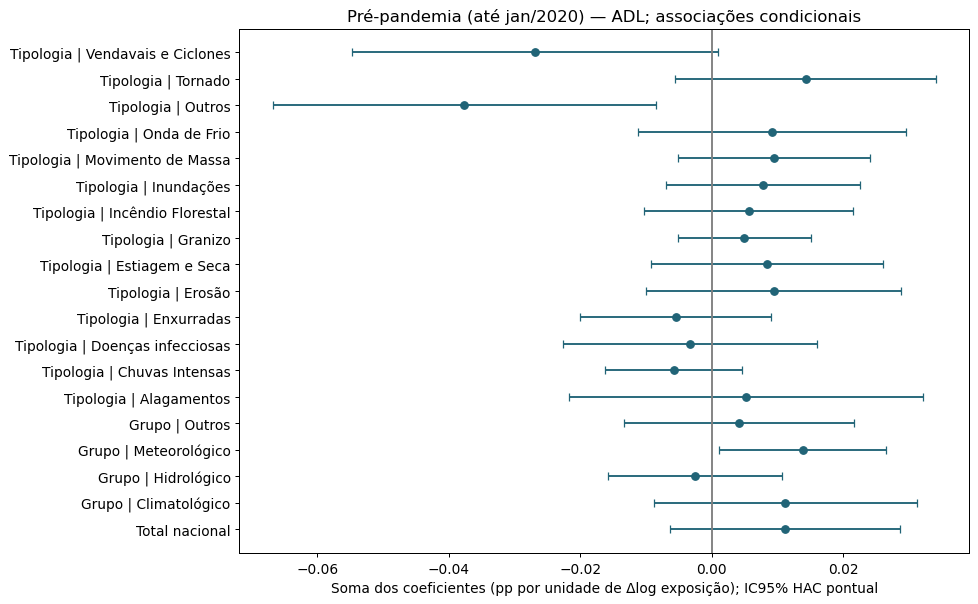

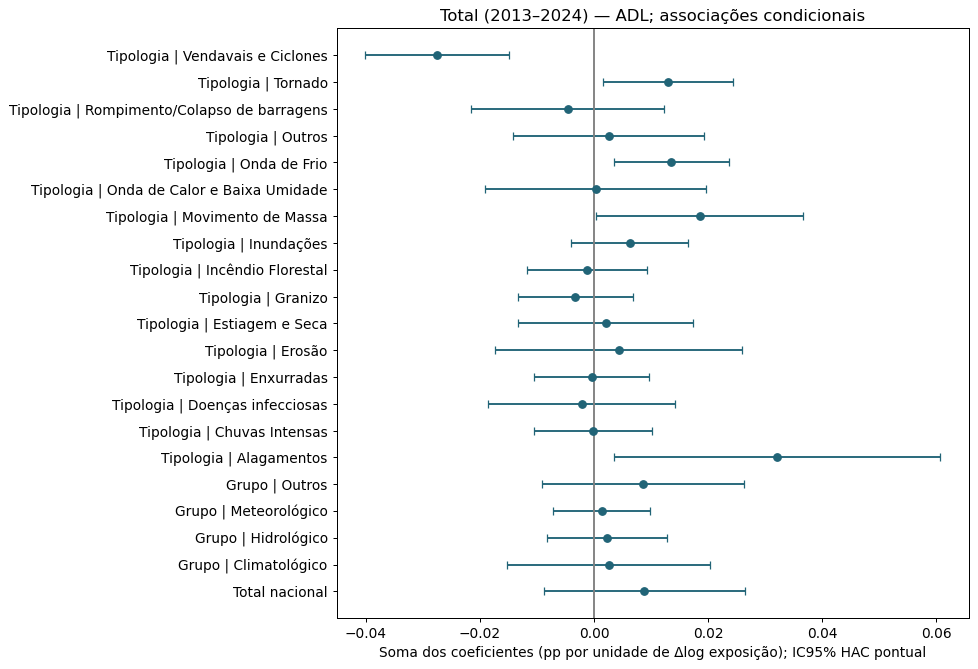

In [5]:
tabela(r[['Período','Exposição','Família','Soma coeficientes','IC baixo','IC alto','BP p','ARCH3 p','RESET p','Mês influente','Δ soma influência','Categoria resultado']])
figura_nacional(r)

## 5. Comparação e decisões de robustez
BG avalia a equação de inadimplência; Portmanteau antigo avalia o sistema. Não comparar percentuais como se fossem o mesmo teste. Toda–Yamamoto depende da triagem definida previamente. Bootstrap temporal e simulação de poder não serão usados para resgatar um modelo reprovado.

In [6]:
tabela(ty(['Total nacional'],extra=False))
tabela(decisions())
checkpoint('10')

,Período,Exposição,Família,d_max,p,Diagnóstico favorável,k,Lags totais,Restrições,Wald chi2,n efetivo,Portmanteau p,Motivo,Família n,p BH,p BY,p Holm,Categoria resultado
0,Total (2013–2024),Total nacional,TY,1,0.42894,True,2.0,3.0,"D1..Dk, sem restringir lag adicional",1.69285,141.0,0.12949,Robustez em níveis: integração limite I(1); ra...,4,1.0,1.0,1.0,Não significativo
1,Pré-pandemia (até jan/2020),Total nacional,TY,1,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,Gate: integração/dinâmica ADL inadequada ou in...,4,1.0,1.0,1.0,Excluído / inviável


,Procedimento,Decisão,Justificativa
0,Bootstrap temporal H0,Não aplicado,Teste condicional à seleção; bootstrap defensá...
1,Simulação de poder,Não aplicada,Não atribuir tamanho/poder confiável a um DGP ...
2,Controles econômicos adicionais,Não incluídos,Não disponíveis na entrada com cobertura ofici...
3,GMM,Não aplicado,"N=27,T longo; evitar proliferação de instrumen..."


/root/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/root/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/root/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/root/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/root/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self.